# Backends: Orbits

This notebook describes how to integrate orbits with
[JAX](https://docs.jax.dev/) and [PyTorch](https://pytorch.org/) and how to
differentiate them: with respect to their initial conditions and with
respect to the parameters of the potential, in forward and reverse mode, for
single orbits and for batches of orbits. See the [quick
start](quickstart.ipynb) for an introduction to galpy's backends.

In [1]:
%matplotlib inline
import time

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

import galpy.backend
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential, MWPotential2014, PlummerPotential

ic = [1.0, 0.1, 1.1, 0.1, 0.05, 0.0]  # R,vR,vT,z,vz,phi
ts = numpy.linspace(0.0, 10.0, 101)

## Two ways to integrate an orbit on a backend

An `Orbit` whose initial condition is a JAX array or a PyTorch tensor can be
integrated in two ways:

1. **In the backend**, with the backend's own ODE solver:
   [diffrax](https://docs.kidger.site/diffrax/) for JAX (`method="diffrax"`,
   an eighth-order Dormand-Prince method) and
   [torchode](https://github.com/martenlienen/torchode) or
   [torchdiffeq](https://github.com/rtqichen/torchdiffeq) for PyTorch
   (`method="torchode"` or `method="torchdiffeq"`, a fifth-order
   Dormand-Prince method). The whole integration is then a JAX or PyTorch
   computation, so everything that enters it can be differentiated: the
   initial condition, the parameters of the potential, and the times. It runs
   on a GPU when the initial condition is on a GPU.
2. **With galpy's C integrators**, which are much faster on a CPU but opaque
   to automatic differentiation. When the initial condition is
   differentiated, galpy integrates the variational equations alongside the
   orbit in C and uses the resulting state-transition matrix as the
   derivative of the orbit with respect to its initial condition. This gives
   derivatives with respect to the initial condition only, to first order.

The in-backend integration agrees with the C integrator to the tolerance of
the integrators (the default tolerances are $10^{-12}$):

In [2]:
o = Orbit(jnp.asarray(ic))
o.integrate(ts, MWPotential2014, method="diffrax")
oc = Orbit(ic)
oc.integrate(ts, MWPotential2014, method="dop853_c")
print(type(o.R(ts)))
print("diffrax vs. C:", numpy.max(numpy.fabs(numpy.asarray(o.R(ts)) - oc.R(ts))))

<class 'jaxlib._jax.ArrayImpl'>
diffrax vs. C: 3.7809977371239256e-11


In [3]:
ot = Orbit(torch.tensor(ic, dtype=torch.float64))
ot.integrate(torch.as_tensor(ts), MWPotential2014, method="torchode")
print(type(ot.R(ts)))
print("torchode vs. C:", numpy.max(numpy.fabs(ot.R(ts).numpy() - oc.R(ts))))

<class 'torch.Tensor'>
torchode vs. C: 4.316547119742609e-12


After the integration, the orbit's methods work as usual and return backend
arrays: positions and velocities at the integration times or, through an
in-backend spline, between them, energies, angular momenta, observed
coordinates, pericenters, apocenters, and so on:

In [4]:
print(o.E(ts[-1]), o.Lz(ts[-1]), o.rperi(), o.rap(), o.zmax())

-0.7418820418152636 1.1000000000000039 0.9838816729764085 1.326394653211149 0.1306105923204673


Inside a `galpy.backend.use("jax")` (or `"torch"`) block, an `Orbit` set up
from Python floats is a JAX (or PyTorch) orbit, the same as one set up from a
backend array:

In [5]:
with galpy.backend.use("jax"):
    o2 = Orbit(ic)
o2.integrate(ts, MWPotential2014, method="diffrax")
print(type(o2.R(ts)), numpy.max(numpy.fabs(o2.R(ts) - o.R(ts))))

<class 'jaxlib._jax.ArrayImpl'> 0.0


## Derivatives with respect to the initial condition

Any function of an orbit integrated in the backend can be differentiated
with respect to the initial condition. For example, the sensitivity of
$R(t)$ and $z(t)$ to the initial condition, as a function of time, for an
orbit in a Plummer potential, by reverse-mode differentiation with
`jax.jacrev`:

In [6]:
pp = PlummerPotential(amp=1.0, b=0.6)
ts_short = numpy.linspace(0.0, 10.0, 101)


def Rz(ic):
    o = Orbit(ic)
    o.integrate(ts_short, pp, method="diffrax")
    return jnp.stack([o.R(ts_short), o.z(ts_short)])


dRz = jax.jacrev(Rz)(jnp.asarray(ic))
print(dRz.shape)  # (R/z, time, initial condition)

(2, 101, 6)


We compare $\partial R(t)/\partial R_0$, $\partial R(t)/\partial v_{R,0}$,
$\partial z(t)/\partial z_0$, and $\partial z(t)/\partial v_{z,0}$ with
central finite differences of C orbits:

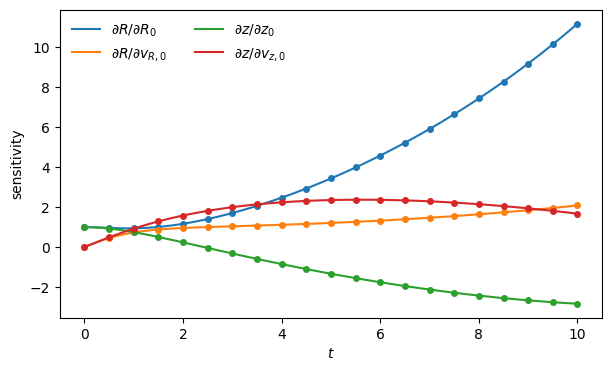

In [7]:
def Rz_c(ic):
    o = Orbit(list(ic))
    o.integrate(ts_short, pp, method="dop853_c")
    return numpy.array([o.R(ts_short), o.z(ts_short)])


h = 1e-6
plt.figure(figsize=(7, 4))
for row, col, label in [
    (0, 0, r"\partial R/\partial R_0"),
    (0, 1, r"\partial R/\partial v_{R,0}"),
    (1, 3, r"\partial z/\partial z_0"),
    (1, 4, r"\partial z/\partial v_{z,0}"),
]:
    e = numpy.zeros(6)
    e[col] = h
    fd = (Rz_c(numpy.array(ic) + e) - Rz_c(numpy.array(ic) - e))[row] / (2.0 * h)
    (line,) = plt.plot(ts_short, dRz[row, :, col], label=rf"${label}$")
    plt.plot(ts_short[::5], fd[::5], "o", color=line.get_color(), ms=4)
plt.xlabel(r"$t$")
plt.ylabel("sensitivity")
plt.legend(frameon=False, ncol=2);

Lines are the automatic derivative, points the finite differences.

With PyTorch, the initial condition is a tensor that requires a gradient:

In [8]:
ict = torch.tensor(ic, dtype=torch.float64, requires_grad=True)
ot = Orbit(ict)
ot.integrate(torch.as_tensor(ts_short), pp, method="torchode")
ot.R(ts_short[-1]).backward()
print(ict.grad)
print(dRz[0, -1])

tensor([1.1152e+01, 2.0819e+00, 2.1453e+01, 9.3785e-01, 1.0917e+00, 7.3328e-12],
       dtype=torch.float64)
[1.11521107e+01 2.08188149e+00 2.14529659e+01 9.37854038e-01
 1.09167699e+00 8.88178420e-15]


## Derivatives with respect to the parameters of the potential

The in-backend integration is also differentiable with respect to the
parameters of the potential. Set up the potential with the parameter inside
the function that you differentiate:

In [9]:
def final_R(b):
    o = Orbit(jnp.asarray(ic))
    o.integrate(ts_short, PlummerPotential(amp=1.0, b=b), method="diffrax")
    return o.R(ts_short[-1])


dRdb = jax.grad(final_R)(0.6)


def final_R_c(b):
    o = Orbit(ic)
    o.integrate(ts_short, PlummerPotential(amp=1.0, b=b), method="dop853_c")
    return o.R(ts_short[-1])


h = 1e-5
print(dRdb, (final_R_c(0.6 + h) - final_R_c(0.6 - h)) / (2.0 * h))

7.691099584358614 7.691099584006266


With PyTorch, give the parameter as a tensor that requires a gradient:

In [10]:
b = torch.tensor(0.6, dtype=torch.float64, requires_grad=True)
ot = Orbit(torch.tensor(ic, dtype=torch.float64))
ot.integrate(
    torch.as_tensor(ts_short), PlummerPotential(amp=1.0, b=b), method="torchode"
)
ot.R(ts_short[-1]).backward()
print(b.grad)

tensor(7.6911, dtype=torch.float64)


As an example, we fit the flattening $q$ of a logarithmic halo to the $x$
and $z$ coordinates along an orbit, which we generate with $q=0.85$. The
loss function contains the orbit integration and is differentiated and
compiled with `jax.jit(jax.value_and_grad(...))`; after the first call,
which compiles the function, each evaluation is fast:

In [11]:
ts_fit = numpy.linspace(0.0, 5.0, 51)
o_obs = Orbit(ic)
o_obs.integrate(
    ts_fit, LogarithmicHaloPotential(normalize=1.0, q=0.85), method="dop853_c"
)
x_obs, z_obs = o_obs.x(ts_fit), o_obs.z(ts_fit)


def loss(q):
    pot = LogarithmicHaloPotential(normalize=1.0, q=q)
    o = Orbit(jnp.asarray(ic))
    o.integrate(ts_fit, pot, method="diffrax")
    return jnp.sum((o.x(ts_fit) - x_obs) ** 2 + (o.z(ts_fit) - z_obs) ** 2)


loss_and_grad = jax.jit(jax.value_and_grad(loss))
start = time.perf_counter()
loss_and_grad(1.0)
print(f"First call (compiles): {time.perf_counter() - start:.2f} s")
start = time.perf_counter()
loss_and_grad(1.0)
print(f"Second call: {time.perf_counter() - start:.4f} s")

First call (compiles): 5.96 s
Second call: 0.0062 s


The compiled loss and gradient can be passed to any optimizer, for example
to `scipy.optimize.minimize`:

In [12]:
from scipy import optimize


def fun(p):
    val, grad = loss_and_grad(float(p[0]))
    return float(val), numpy.array([float(grad)])


res = optimize.minimize(
    fun,
    x0=[1.0],
    jac=True,
    method="L-BFGS-B",
    bounds=[(0.5, 1.5)],
    options={"ftol": 1e-15, "gtol": 1e-12},
)
print(f"q = {res.x[0]:.10f} after {res.nfev} evaluations")

q = 0.8500000000 after 10 evaluations


## galpy's C integrators and the state-transition matrix

For derivatives with respect to the initial condition, galpy's C
integrators are usually the fastest option on a CPU. When an orbit with a
JAX or PyTorch initial condition is integrated with a C Runge-Kutta method
(e.g., `method="dop853_c"`) and the initial condition is differentiated,
galpy integrates the variational equations in C together with the orbit and
uses the resulting state-transition matrix,
$\mathsf{M}(t) = \partial \vec{w}(t)/\partial \vec{w}(0)$, as the derivative.
The reverse-mode derivative of a function of the orbit is then a single
product of $\mathsf{M}^\mathsf{T}$ with the incoming gradient. In code,
nothing changes except the method:

In [13]:
def end_point(ic, method="dop853_c"):
    o = Orbit(ic)
    o.integrate(ts, MWPotential2014, method=method)
    return jnp.stack([o.R(ts[-1]), o.z(ts[-1])])


start = time.perf_counter()
M = jax.jacrev(end_point)(jnp.asarray(ic))
print(f"C + variational equations: {time.perf_counter() - start:.2f} s")
start = time.perf_counter()
M_diffrax = jax.jacrev(lambda ic: end_point(ic, method="diffrax"))(jnp.asarray(ic))
print(f"diffrax: {time.perf_counter() - start:.2f} s")
print(M)
print("Largest difference:", numpy.max(numpy.fabs(M - M_diffrax)))

C + variational equations: 1.29 s


diffrax: 15.81 s
[[ 3.31952696e+00 -3.73197600e-01  3.83162031e+00  9.13509656e-01
   9.60332473e-02 -1.95030394e-15]
 [ 2.86598718e+00  3.58999086e-01  3.86735032e+00  5.86027792e+00
   1.53497260e+00 -8.92494597e-17]]
Largest difference: 1.743583055713316e-11


The same works with PyTorch:

In [14]:
def end_point_torch(ic):
    o = Orbit(ic)
    o.integrate(ts, MWPotential2014, method="dop853_c")
    return torch.stack([o.R(ts[-1]), o.z(ts[-1])])


Mt = torch.autograd.functional.jacobian(
    end_point_torch, torch.tensor(ic, dtype=torch.float64)
)
print(
    "Largest difference with JAX:", numpy.max(numpy.fabs(Mt.numpy() - numpy.asarray(M)))
)

Largest difference with JAX: 0.0


galpy chooses between the C integrators and the in-backend solvers as
follows. An orbit with a backend initial condition that is integrated with a
C Runge-Kutta method (`"rk4_c"`, `"rk6_c"`, `"dopr54_c"`, `"dop853_c"`), in a
potential that is implemented in C, with times and potential parameters that
are not being differentiated or compiled, uses the C integrator and, when the
initial condition is differentiated, its variational equations. The
symplectic C methods (including the default `"symplec4_c"`) do so only when
the initial condition is differentiated. In every other case, in particular
when a parameter of the potential is differentiated, the orbit must be
integrated in the backend with `method="diffrax"`, `"torchode"`, or
`"torchdiffeq"`. An orbit with a concrete (not differentiated) backend
initial condition that is integrated with a method that is not routed to
either path is integrated in C and returned as backend arrays that do not
carry a derivative, with a warning.

The variational equations themselves are also available directly through
`Orbit.integrate_dxdv` and `Orbit.lyapunov` (see [Phase-Space Volumes and
Chaos](../orbits/phase_space_volumes_and_chaos.ipynb)).

## Batches of orbits and `jax.vmap`

An `Orbit` set up from a backend array of shape `(N, 6)` integrates all
orbits in a single in-backend solve:

In [15]:
ics = jnp.array(
    [
        [1.0, 0.1, 1.1, 0.1, 0.05, 0.0],
        [0.9, -0.1, 1.0, 0.0, 0.1, 0.5],
        [1.2, 0.2, 0.9, -0.1, 0.0, 1.0],
    ]
)
ob = Orbit(ics)
ob.integrate(ts, MWPotential2014, method="diffrax")
print(ob.R(ts).shape)

(3, 101)


A function of a single orbit can be vectorized over initial conditions with
`jax.vmap`, also when it uses the C integrator and its state-transition
matrix:

In [16]:
Ms = jax.vmap(jax.jacrev(end_point))(ics)
print(Ms.shape)

(3, 2, 6)


## Forward and reverse mode, second derivatives

By default, diffrax differentiates the solve in reverse mode with a
checkpointed adjoint (`jax.grad`, `jax.jacrev`, `jax.vjp`), which does not
support forward mode. When galpy sees a forward-mode derivative (`jax.jvp`,
`jax.jacfwd`), it uses diffrax's direct adjoint instead, which
differentiates through the solver's internal operations. Forward mode is
more efficient when there are few inputs and many outputs:

In [17]:
dRz_fwd = jax.jacfwd(Rz)(jnp.asarray(ic))
print("jacfwd vs. jacrev:", numpy.max(numpy.fabs(dRz_fwd - dRz)))

jacfwd vs. jacrev: 4.076738946423575e-10


The same holds for second derivatives that apply forward mode to a
reverse-mode derivative, such as `jax.hessian`. For the second derivative of
the final radius with respect to the scale parameter of the Plummer
potential, compared with a finite difference of C orbits:

In [18]:
h = 1e-4
print(
    jax.hessian(final_R)(0.6),
    (final_R_c(0.6 + h) - 2.0 * final_R_c(0.6) + final_R_c(0.6 - h)) / h**2,
)

-6.026562754144603 -6.026563914574012


galpy cannot see a forward-mode derivative of a function that has already
been compiled with `jax.jit` (`jax.jacfwd(jax.jit(f))`; compiling the
derivative, `jax.jit(jax.jacfwd(f))`, is fine), nor reverse mode applied
twice. In those cases, select the direct adjoint yourself with
`inbackend_kwargs={"adjoint": "direct"}`:

In [19]:
def Rz_direct(ic):
    o = Orbit(ic)
    o.integrate(ts_short, pp, method="diffrax", inbackend_kwargs={"adjoint": "direct"})
    return jnp.stack([o.R(ts_short), o.z(ts_short)])


dRz_fwd = jax.jacfwd(jax.jit(Rz_direct))(jnp.asarray(ic))
print("jacfwd of a compiled function vs. jacrev:", numpy.max(numpy.fabs(dRz_fwd - dRz)))

jacfwd of a compiled function vs. jacrev: 4.076738946423575e-10


The in-backend solver can also take a constant number of steps instead of
adaptive ones, with `inbackend_kwargs={"nsteps": ...}`. galpy uses constant
steps where it differentiates batches of orbits under `jax.vmap` internally,
because the step-size control of an adaptive solve can couple the orbits in
a batch; for the orbits here, adaptive and constant steps give the same
derivative. With `jax.vmap` and forward mode:

In [20]:
def end_point_fwd(ic, nsteps=None):
    o = Orbit(ic)
    o.integrate(
        ts,
        MWPotential2014,
        method="diffrax",
        inbackend_kwargs={"nsteps": nsteps},
    )
    return jnp.stack([o.R(ts[-1]), o.z(ts[-1])])


Ms_fwd = jax.vmap(jax.jacfwd(lambda ic: end_point_fwd(ic, nsteps=4000)))(ics)
print(
    "Relative difference with C:",
    numpy.max(numpy.fabs(Ms_fwd - Ms)) / numpy.max(numpy.fabs(Ms)),
)

Relative difference with C: 9.993579409710479e-12


## GPUs

The in-backend solvers run on a GPU when the initial condition is on the
GPU (galpy's C integrators run on the CPU). With PyTorch, put the initial
condition on the device; the following runs on a GPU when one is available:

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
og = Orbit(torch.tensor(ic, dtype=torch.float64, device=device))
og.integrate(ts, MWPotential2014, method="torchode")
print(og.R(ts).device)

cpu


With JAX, arrays are created on the GPU by default when the CUDA-enabled
version of JAX is installed, and `method="diffrax"` then integrates there.

On a CPU, the C integrators are the fastest way to integrate a single orbit
or a few thousand orbits and to obtain their derivatives with respect to
the initial conditions. The in-backend solvers start from a floor of a
second or more, set by compilation, and are most useful for derivatives with
respect to the potential, inside larger compiled programs, and for large
batches of orbits on a GPU.